<a href="https://colab.research.google.com/github/naomicouriel/quantum-jam/blob/main/hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QuantumJam 2025: QKD BB84 en Simuladores Ruidosos
**Autores:** Juan Quiroga Bonetto, Naomi Couriel, Ana Paula Tissera y Athina Salim

## 1. El Problema: El Ocaso de RSA y la Doble Solución Cuántica
La criptografía de clave pública actual (como RSA) se basa en problemas matemáticos que son intratables para las computadoras clásicas. Sin embargo, el algoritmo de Shor los vuelve triviales para una computadora cuántica, creando una amenaza existencial para nuestras comunicaciones seguras.

Ante esto, la comunidad científica ha propuesto dos soluciones distintas:
1.  **Criptografía Poscuántica (PQC):** Algoritmos *clásicos* (basados en matemáticas) que se cree que son resistentes a los ataques cuánticos.
2.  **Distribución Cuántica de Claves (QKD):** Protocolos que usan la *física* cuántica para distribuir una clave. Su seguridad no se basa en suposiciones matemáticas, sino en las leyes de la naturaleza.

## 2. Nuestra Misión: Del Modelo Ideal al Caos del Ruido
En este notebook, implementamos el protocolo **BB84**, el pilar de QKD.

Pero no nos detenemos en una simulación ideal. Nuestro objetivo es investigar la **viabilidad práctica** del protocolo. Para ello, usamos `NoiseModel` de Qiskit Aer para simular las imperfecciones del hardware real (errores de lectura, decoherencia, pérdida de fotones) y analizar cómo este ruido impacta la métrica de seguridad clave: la **Tasa de Error de Bits Cuánticos (QBER)**.

In [ ]:
%pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.4/377.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.7 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e69ed4ad3f04a2ac8e075fd56518b181624009103a790f13831e9e177dd4dc7f
  Stored in di

# Protocolo BB84 de Distribución Cuántica de Claves (QKD)

## Introducción

La **Distribución Cuántica de Claves (QKD)** representa una solución revolucionaria frente a las amenazas que la computación cuántica plantea a la criptografía clásica (RSA, ECC). A diferencia de los esquemas basados en factorización, QKD utiliza las propiedades fundamentales de la mecánica cuántica para garantizar la seguridad de la comunicación.

### El Protocolo BB84

En 1984, Charles Bennett y Gilles Brassard propusieron el protocolo **BB84**, el primer esquema de QKD. Los principios fundamentales son:

1. **Codificación cuántica**: Alice prepara qubits en dos bases diferentes (Z y X)
2. **Medición aleatoria**: Bob mide con bases aleatorias
3. **Reconciliación de bases**: Alice y Bob comparan bases públicamente
4. **Detección de espías**: Cualquier interceptación introduce errores detectables

### Formalismo Matemático

#### Estados Cuánticos

En la **base Z** (computacional):
$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \quad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

En la **base X** (Hadamard):
$$|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle), \quad |-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$$

#### Tasa de Error Cuántica (QBER)

La seguridad del protocolo se basa en el **QBER** (Quantum Bit Error Rate):

$$\text{QBER} = \frac{\text{bits erróneos}}{\text{bits totales comparados}}$$

- **QBER ≈ 0%**: Canal seguro, sin espía
- **QBER ≈ 25%**: Espía presente (ataque intercept-resend)
- **QBER > 11%**: Umbral de seguridad comprometido

#### Probabilidad de Detección

Con $m$ bits de prueba, la probabilidad de detectar a Eve es:

$$P_d = 1 - (0.75)^m$$

Para $m = 50$, $P_d \approx 99.9999\%$


## Implementación

En este notebook implementaremos:

1. **Protocolo BB84 básico**: Codificación, transmisión y medición de qubits
2. **Detección de espías**: Estimación del QBER y verificación de seguridad
3. **Modelos de ruido**: Simulación de canales cuánticos realistas
4. **Post-procesamiento**: Reconciliación de errores (Cascade) y amplificación de privacidad
5. **Aplicación práctica**: Cifrado simétrico con la clave generada
6. **Análisis de rendimiento**: Métricas y visualizaciones

---

## 1. Instalación de Dependencias


---

## 2. Imports y Configuración Global

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import io
import hashlib
import os
import base64
import time

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, phase_damping_error,
    amplitude_damping_error, ReadoutError
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

from cryptography.fernet import Fernet
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.pbkdf2 import PBKDF2HMAC
from cryptography.hazmat.backends import default_backend

# Parámetros globales del protocolo BB84
N_QUBITS = 200        # Número de qubits a transmitir
TEST_SIZE = 50        # Bits para verificación de seguridad
QBER_THRESHOLD = 0.11 # Umbral de error máximo (11%)
BLOCK_SIZE = 4        # Tamaño de bloque para reconciliación

# Semilla para reproducibilidad
np.random.seed(42)

print("✓ Configuración inicializada")
print(f"  N_QUBITS: {N_QUBITS}")
print(f"  TEST_SIZE: {TEST_SIZE}")
print(f"  QBER_THRESHOLD: {QBER_THRESHOLD*100}%")


✓ Configuración inicializada
  N_QUBITS: 200
  TEST_SIZE: 50
  QBER_THRESHOLD: 11.0%


## Decisiones de Diseño: Los Parámetros de Seguridad
La configuración de un protocolo QKD es un balance entre eficiencia y seguridad. Nuestras decisiones clave son:

* **`N_QUBITS` vs. `TEST_SIZE` (El *Trade-off*):**
    `TEST_SIZE` define cuántos bits sacrificamos para buscar a Eve. Una `TEST_SIZE` más grande nos da una estimación del QBER más precisa y, por tanto, más seguridad. Sin embargo, cada bit de prueba es un bit que no podemos usar para nuestra clave final. Es un *trade-off* directo entre **seguridad y tasa de generación de clave**.

* **`QBER_THRESHOLD = 0.11` (El Límite Teórico):**
    Este no es un número arbitrario. La teoría de seguridad de BB84 (específicamente contra ataques de "interceptar-reenviar" o *Intercept-Resend*) demuestra que si el QBER es **menor al 11%**, la amplificación de privacidad puede destilar una clave secreta. Si el QBER supera el 11%, Eve podría tener más información sobre la clave que Alice y Bob, y el protocolo **debe ser abortado**. Es nuestro "interruptor de seguridad".

---

## 3. Funciones Auxiliares del Protocolo BB84

### 3.1 Codificación de Qubits

Fase 1: El Intercambio Cuántico
Esta es la única fase que involucra hardware cuántico (o su simulación).

1.  **Alice (Codificación):** Genera sus bits y bases aleatorias. Prepara sus qubits (`|0⟩`, `|1⟩`, `|+⟩`, `|−⟩`) según esta elección.
2.  **El Canal (El Ruido):** Aquí es donde introducimos nuestro `NoiseModel`. No simulamos un canal perfecto; simulamos uno donde los qubits pueden decaer (`AmplitudeDamping`), perder coherencia (`PhaseDamping`) o ser leídos incorrectamente (`ReadoutError`).
3.  **Bob (Medición):** Elige sus bases aleatorias y mide los qubits que le llegan (ya afectados por el ruido).

In [ ]:
def encode_qubit(bit, base):
    """
    Codifica un bit clásico en un qubit según la base especificada.

    Args:
        bit (int): Bit clásico (0 o 1)
        base (int): Base de codificación (0=Z, 1=X)

    Returns:
        QuantumCircuit: Circuito cuántico con el qubit codificado
    """
    qc = QuantumCircuit(1, 1)

    if bit == 1:
        qc.x(0)

    if base == 1:
        qc.h(0)

    return qc


def measure_qubit(qc, base):
    """
    Añade medición al circuito en la base especificada.

    Args:
        qc (QuantumCircuit): Circuito cuántico
        base (int): Base de medición (0=Z, 1=X)

    Returns:
        QuantumCircuit: Circuito con medición añadida
    """
    if base == 1:
        qc.h(0)

    qc.measure(0, 0)
    return qc


### 3.2 Funciones de Generación y Medición


In [ ]:
def generar_datos_alice(n):
    """
    Genera bits y bases aleatorias para Alice.

    Args:
        n (int): Número de qubits a generar

    Returns:
        tuple: (bits_alice, bases_alice)
    """
    bits_alice = np.random.randint(2, size=n)
    bases_alice = np.random.randint(2, size=n)
    return bits_alice, bases_alice


def codificar_qubits(bits, bases):
    """
    Crea circuitos cuánticos para cada par bit-base.

    Args:
        bits (array): Array de bits clásicos
        bases (array): Array de bases de codificación

    Returns:
        list: Lista de QuantumCircuit
    """
    lista_circuitos = []
    for bit, base in zip(bits, bases):
        qc = QuantumCircuit(1, 1)

        if bit == 1:
            qc.x(0)

        if base == 1:
            qc.h(0)

        qc.id(0)  # Compuerta identidad para simular ruido en el canal cuántico
        lista_circuitos.append(qc)

    return lista_circuitos


def generar_bases_bob(n):
    """
    Genera bases de medición aleatorias para Bob.

    Args:
        n (int): Número de bases a generar

    Returns:
        array: Bases de medición aleatorias
    """
    return np.random.randint(2, size=n)


def medir_qubits_bob(lista_circuitos, bases_bob, pm, sampler_inst):
    """
    Simula la medición de Bob sobre los qubits recibidos.

    Args:
        lista_circuitos (list): Lista de circuitos cuánticos
        bases_bob (array): Bases de medición de Bob
        pm (PassManager): Pass manager para transpilación
        sampler_inst (Sampler): Sampler para ejecución

    Returns:
        array: Bits medidos por Bob
    """
    bits_bob = []
    circuitos_medicion = []

    for i, qc in enumerate(lista_circuitos):
        base_bob = bases_bob[i]

        if base_bob == 1:
            qc.h(0)

        qc.measure(0, 0)
        circuitos_medicion.append(qc)

    circuitos_isa = pm.run(circuitos_medicion)
    job = sampler_inst.run(circuitos_isa, shots=1)
    result = job.result()

    for pub_result in result:
        counts = pub_result.data.c.get_counts()
        measured_bit_str = list(counts.keys())[0]
        bits_bob.append(int(measured_bit_str))

    return np.array(bits_bob)


### 3.3 Sifting y Verificación de Seguridad


Fase 2: Sifting (La Conversación Clásica)
El primer paso del post-procesamiento. Alice y Bob revelan públicamente (por un canal clásico) **solo las bases** que usaron para cada qubit.

* Si las bases coinciden (ej. ambos usaron la base Z), conservan el bit.
* Si las bases no coinciden (ej. Alice usó Z y Bob usó X), el resultado es aleatorio y el bit se **descarta**.

Estadísticamente, esto elimina aproximadamente el 50% de los qubits intercambiados, resultando en la "Clave Filtrada" (*Sifted Key*).

In [ ]:
def sift_keys(bases_alice, bases_bob, bits_alice, bits_bob):
    """
    Compara bases y filtra bits donde coincidieron.

    Args:
        bases_alice (array): Bases de Alice
        bases_bob (array): Bases de Bob
        bits_alice (array): Bits de Alice
        bits_bob (array): Bits medidos por Bob

    Returns:
        tuple: (sifted_alice, sifted_bob)
    """
    sifted_alice = []
    sifted_bob = []

    for i in range(len(bases_alice)):
        if bases_alice[i] == bases_bob[i]:
            sifted_alice.append(bits_alice[i])
            sifted_bob.append(bits_bob[i])

    return np.array(sifted_alice), np.array(sifted_bob)


def check_for_eve(sifted_key_alice, sifted_key_bob, test_size):
    """
    Calcula el QBER comparando una muestra de bits.

    Args:
        sifted_key_alice (array): Clave filtrada de Alice
        sifted_key_bob (array): Clave filtrada de Bob
        test_size (int): Número de bits a comparar

    Returns:
        tuple: (qber, final_key_alice)
    """
    if len(sifted_key_alice) < test_size:
        return None, None

    test_bits_alice = sifted_key_alice[:test_size]
    test_bits_bob = sifted_key_bob[:test_size]

    diferencias = np.sum(test_bits_alice != test_bits_bob)
    qber = diferencias / test_size

    final_key_alice = sifted_key_alice[test_size:]

    return qber, final_key_alice


---

## 4. Post-Procesamiento

### 4.1 Reconciliación de Errores (Protocolo Cascade)

El protocolo **Cascade** permite corregir errores mediante búsqueda binaria iterativa:

1. Divide la clave en bloques
2. Compara paridades públicamente
3. Localiza errores mediante búsqueda binaria
4. Aplica múltiples pasadas con barajado (shuffling)


## Fase 4: Defensa contra el Espía Clásico
El QBER nos protegió del espía cuántico. Pero, ¿qué pasa con el **espía clásico**? Un espía que simplemente *escucha* toda nuestra conversación pública (Sifting, QBER, y Reconciliación).

Este espía no puede ser *detectado*, pero su conocimiento debe ser *anulado*. Esto se hace en dos pasos:

## Reconciliación de Errores (con Cascade)
* **Propósito:** Corregir los errores *naturales* (el QBER < 11% que aceptamos) para que Alice y Bob tengan claves idénticas.
* **El Peligro:** Al discutir la paridad de los bloques de su clave para encontrar errores, Alice y Bob están **revelando información pública** (metadatos) sobre su clave. El espía clásico anota todo.


In [ ]:
def _cascade_binary_search(alice_key, bob_key_to_correct, start, end):
    """
    Búsqueda binaria recursiva para localizar errores en un bloque.

    Args:
        alice_key (array): Clave de Alice (referencia)
        bob_key_to_correct (array): Clave de Bob (se modifica in-place)
        start (int): Índice inicial del bloque
        end (int): Índice final del bloque

    Returns:
        int: Número de errores encontrados
    """
    if (end - start) == 1:
        bob_key_to_correct[start] = 1 - bob_key_to_correct[start]
        return 1

    mid_point = start + (end - start) // 2
    errors_found = 0

    parity_alice_left = np.sum(alice_key[start:mid_point]) % 2
    parity_bob_left = np.sum(bob_key_to_correct[start:mid_point]) % 2

    if parity_alice_left != parity_bob_left:
        errors_found += _cascade_binary_search(alice_key, bob_key_to_correct, start, mid_point)

    parity_alice_right = np.sum(alice_key[mid_point:end]) % 2
    parity_bob_right = np.sum(bob_key_to_correct[mid_point:end]) % 2

    if parity_alice_right != parity_bob_right:
        errors_found += _cascade_binary_search(alice_key, bob_key_to_correct, mid_point, end)

    return errors_found


def _cascade_pass(alice_key, bob_key_to_correct, block_size):
    """
    Ejecuta una pasada completa de Cascade.

    Args:
        alice_key (array): Clave de Alice
        bob_key_to_correct (array): Clave de Bob
        block_size (int): Tamaño de los bloques

    Returns:
        int: Número de errores encontrados
    """
    errors_found_pass = 0
    num_blocks = len(alice_key) // block_size

    if num_blocks == 0:
        return 0

    for i in range(num_blocks):
        start_index = i * block_size
        end_index = (i + 1) * block_size

        block_alice = alice_key[start_index:end_index]
        block_bob = bob_key_to_correct[start_index:end_index]

        parity_alice = np.sum(block_alice) % 2
        parity_bob = np.sum(block_bob) % 2

        if parity_alice != parity_bob:
            errors_found_pass += _cascade_binary_search(
                alice_key, bob_key_to_correct, start_index, end_index
            )

    return errors_found_pass


def reconcile_keys_cascade(alice_key, bob_key, num_passes=4):
    """
    Implementa el protocolo CASCADE completo con múltiples pasadas.

    Args:
        alice_key (array): Clave de Alice
        bob_key (array): Clave de Bob con errores
        num_passes (int): Número de pasadas (default: 4)

    Returns:
        tuple: (alice_key_corrected, bob_key_corrected)
    """
    print(f"\nReconciliación Cascade ({num_passes} pasadas)...")

    bob_key_corrected = np.copy(bob_key)
    n = len(alice_key)

    block_sizes = [8 * (2**i) for i in range(num_passes)]
    permutations = []

    total_errors_corregidos = 0

    for i in range(num_passes):
        block_size = block_sizes[i]
        print(f"  Pasada {i+1}/{num_passes} (bloque={block_size})...", end=" ")

        if i > 0:
            perm = np.random.permutation(n)
            permutations.append(perm)
            alice_key = alice_key[perm]
            bob_key_corrected = bob_key_corrected[perm]

        errors = _cascade_pass(alice_key, bob_key_corrected, block_size)
        print(f"{errors} errores corregidos")

        total_errors_corregidos += errors

        print(f"Errores encontrados en esta pasada: {errors}")
        if errors == 0 and i > 0:
            print("No se encontraron más errores, terminando reconciliación.")
            break

    print("  -> Restaurando orden original de la clave (un-shuffling)...")
    for perm in reversed(permutations):
        inv_perm = np.argsort(perm)
        alice_key = alice_key[inv_perm]
        bob_key_corrected = bob_key_corrected[inv_perm]

    errors_remaining = np.sum(alice_key != bob_key_corrected)
    print(f"Errores restantes después de {num_passes} pasadas: {errors_remaining}")

    if errors_remaining == 0:
        print(f" ✓ Reconciliación exitosa - Las claves de Alice y Bob ahora son idénticas.")
    else:
        print(f" {errors_remaining} errores restantes")

    return alice_key, bob_key_corrected, total_errors_corregidos, errors_remaining


def reconcile_keys(alice_key, bob_key, block_size=4):
    """
    Reconciliación simple basada en paridad (descarta bloques con error).

    Args:
        alice_key (array): Clave de Alice
        bob_key (array): Clave de Bob
        block_size (int): Tamaño de bloque

    Returns:
        array: Clave reconciliada
    """
    reconciled_key_alice = []
    num_blocks = len(alice_key) // block_size

    print(f"\nReconciliación de Datos (Block size={block_size})...")

    for i in range(num_blocks):
        start = i * block_size
        end = (i + 1) * block_size

        block_alice = alice_key[start:end]
        block_bob = bob_key[start:end]

        parity_alice = np.sum(block_alice) % 2
        parity_bob = np.sum(block_bob) % 2

        if parity_alice == parity_bob:
            reconciled_key_alice.extend(block_alice)

    print(f"  Bloques conservados: {len(reconciled_key_alice)//block_size}/{num_blocks}")
    print(f"  Tamaño: {len(reconciled_key_alice)} bits")

    return np.array(reconciled_key_alice)


### 4.2 Amplificación de Privacidad

Después de la reconciliación, Eve puede tener información parcial sobre la clave. La **amplificación de privacidad** reduce exponencialmente esta información mediante compresión por XOR o hash criptográfico.


In [ ]:
def amplify_privacy(reconciled_key):
    """
    Amplificación de privacidad mediante plegado con XOR.

    Args:
        reconciled_key (array): Clave reconciliada

    Returns:
        array: Clave final segura (tamaño reducido a la mitad)
    """
    n = len(reconciled_key)
    if n == 0:
        return np.array([])

    half_len = n // 2
    key_half_1 = reconciled_key[:half_len]
    key_half_2 = reconciled_key[half_len : 2 * half_len]

    print(f"\n Amplificación de Privacidad...")
    print(f"  Reduciendo clave de {n} → {half_len} bits")

    final_secure_key = np.bitwise_xor(key_half_1, key_half_2)

    return final_secure_key


---

## 5. Modelos de Ruido Cuántico

Los canales cuánticos reales sufren de varios tipos de ruido:

- **Depolarizing**: Mezcla total del estado cuántico
- **Phase Damping**: Pérdida de coherencia de fase
- **Amplitude Damping**: Pérdida de energía (decaimiento)
- **Readout Error**: Errores en el detector


## Análisis Experimental: Caracterizando al Enemigo
Un protocolo que funciona "en teoría" es solo el comienzo. Ahora, investigamos **cuál es el verdadero enemigo** en un escenario práctico.

Ejecutamos nuestro protocolo BB84 bajo diferentes tipos de ruido simulado, manteniendo constante la probabilidad de error, para responder a la pregunta: **"¿Qué tipo de imperfección física degrada más nuestra seguridad (QBER)?"**

Modelamos:
* **`ReadoutError` (Error de Lectura):** Un error *clásico* en la detección. El detector "ve" un 0 cuando era un 1, o viceversa.
* **`AmplitudeDamping` (Amortiguación de Amplitud):** Simula la *pérdida de energía* de un qubit. Es el análogo cuántico de la atenuación de señal en fibra óptica (un fotón se pierde o decae al estado base `|0⟩`).
* **`DepolarizingError` (Error de Depolarización):** Un modelo de ruido "general" que simula una pérdida aleatoria de información cuántica (el estado del qubit tiende a un estado de mezcla máxima).

In [ ]:
def create_noise_model(p_amp=0.01, p_depol=0.015, p_readout=0.05):
    """
    Crea un modelo de ruido realista combinando múltiples canales.

    Args:
        p_amp (float): Probabilidad de amplitude damping
        p_depol (float): Probabilidad de depolarización
        p_readout (float): Probabilidad de error de lectura

    Returns:
        NoiseModel: Modelo de ruido configurado
    """
    err_amp = amplitude_damping_error(p_amp)
    err_depol = depolarizing_error(p_depol, 1)

    combined_error = err_depol.compose(err_amp)

    err_read = ReadoutError([[1 - p_readout, p_readout],
                            [p_readout, 1 - p_readout]])

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(combined_error,
                                           ['u1', 'u2', 'u3', 'id', 'x', 'h'])
    noise_model.add_all_qubit_readout_error(err_read)

    print(f"✓ Modelo de ruido configurado:")
    print(f"  - Amplitude damping: {p_amp*100}%")
    print(f"  - Depolarizing: {p_depol*100}%")
    print(f"  - Readout: {p_readout*100}%")

    return noise_model


def canal_clasico_con_ruido(bits, p_error_classic):
    """
    Simula errores en el canal clásico público.

    Args:
        bits (array): Bits a transmitir
        p_error_classic (float): Probabilidad de error

    Returns:
        array: Bits con errores introducidos
    """
    flips = np.random.rand(len(bits)) < p_error_classic
    return np.bitwise_xor(bits, flips.astype(int))


def sift_keys_con_ruido_clasico(bases_alice, bases_bob, bits_alice, bits_bob, p_error_classic):
    """
    Sifting con ruido en el canal clásico de comparación de bases.

    Args:
        bases_alice (array): Bases de Alice
        bases_bob (array): Bases de Bob
        bits_alice (array): Bits de Alice
        bits_bob (array): Bits de Bob
        p_error_classic (float): Probabilidad de error clásico

    Returns:
        tuple: (sifted_alice, sifted_bob)
    """
    bases_bob_recibidas = canal_clasico_con_ruido(bases_bob, p_error_classic)
    sifted_a, sifted_b = [], []

    for i in range(len(bases_alice)):
        if bases_alice[i] == bases_bob_recibidas[i]:
            sifted_a.append(bits_alice[i])
            sifted_b.append(bits_bob[i])

    return np.array(sifted_a), np.array(sifted_b)


---

## 6. Clase BB84Protocol

Implementación orientada a objetos del protocolo completo.


## Detección del Espía Cuántico (El QBER)
Esta es nuestra **defensa contra el espía cuántico (Eve)**.

Alice y Bob sacrifican una porción de su clave filtrada (`TEST_SIZE`) y comparan esos bits públicamente.
Cualquier discrepancia se suma al **QBER (Quantum Bit Error Rate)**.

* **¿Por qué Eve introduce errores?** Eve no sabe qué base usó Alice. Si Eve mide en la base equivocada y reenvía el qubit a Bob, tiene un 50% de probabilidad de introducir un error detectable.
* **La Decisión:**
    * `if qber > QBER_THRESHOLD:`: **¡Abortar!** El ruido es demasiado alto. No podemos distinguir el ruido natural de un ataque de Eve. La clave está comprometida.
    * `else:`: El QBER es aceptable. Los errores se deben (en su mayoría) al ruido del canal. Podemos proceder a corregirlos.

In [ ]:
class BB84Protocol:
    """
    Implementación completa del protocolo BB84 con post-procesamiento.

    Attributes:
        n_qubits (int): Número de qubits a transmitir
        test_size (int): Bits para verificación de seguridad
        enable_eve (bool): Activar simulación de espía
        enable_postprocessing (bool): Activar reconciliación y amplificación
        block_size (int): Tamaño de bloque para reconciliación
        use_cascade (bool): Usar Cascade en lugar de reconciliación simple
    """

    def __init__(self, n_qubits=200, test_size=50,
                 noise_model=None, enable_eve=False,
                 enable_postprocessing=False, block_size=4, use_cascade=True):

        self.n_qubits = n_qubits
        self.test_size = test_size
        self.enable_eve = enable_eve
        self.enable_postprocessing = enable_postprocessing
        self.block_size = block_size
        self.use_cascade = use_cascade

        self.alice_bits = None
        self.alice_bases = None
        self.bob_bases = None
        self.bob_results = None
        self.eve_bases = None

        self.sifted_key_alice = None
        self.sifted_key_bob = None
        self.final_key_alice = None
        self.final_key_bob = None
        self.secure_key = None

        self.qber = None
        self.key_indices = None

        backend = AerSimulator(noise_model=noise_model) if noise_model else AerSimulator()
        self.backend = backend
        self.pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
        self.sampler = Sampler(mode=backend)

    def alice_prepare(self):
        """Alice genera bits y bases aleatorias."""
        self.alice_bits = np.random.randint(2, size=self.n_qubits)
        self.alice_bases = np.random.randint(2, size=self.n_qubits)
        print(f"✓ Alice preparó {self.n_qubits} qubits")

    def bob_prepare(self):
        """Bob genera bases aleatorias."""
        self.bob_bases = np.random.randint(2, size=self.n_qubits)
        print(f"✓ Bob preparó {self.n_qubits} bases de medición")

    def eve_intercept(self, circuits):
        """Eve intercepta y reenvía qubits."""
        if not self.enable_eve:
            return circuits

        print(f"⚠️  Eve está interceptando {len(circuits)} qubits...")
        self.eve_bases = np.random.randint(2, size=self.n_qubits)

        eve_circuits = []
        for i, qc in enumerate(circuits):
            qc_copy = qc.copy()
            if self.eve_bases[i] == 1:
                qc_copy.h(0)
            qc_copy.measure(0, 0)
            eve_circuits.append(qc_copy)

        eve_isa = self.pm.run(eve_circuits)
        job = self.sampler.run(eve_isa, shots=1)
        result = job.result()

        eve_bits = [int(list(pub_result.data.c.get_counts().keys())[0])
                    for pub_result in result]

        new_circuits = [encode_qubit(bit, base)
                       for bit, base in zip(eve_bits, self.eve_bases)]

        return new_circuits

    def transmit_and_measure(self):
        """Transmisión cuántica completa."""
        print(f"\n Transmitiendo {self.n_qubits} qubits...")

        circuits = [encode_qubit(self.alice_bits[i], self.alice_bases[i])
                   for i in range(self.n_qubits)]

        circuits = self.eve_intercept(circuits)

        for i in range(self.n_qubits):
            circuits[i] = measure_qubit(circuits[i], self.bob_bases[i])

        circuits_isa = self.pm.run(circuits)
        job = self.sampler.run(circuits_isa, shots=1)
        result = job.result()

        self.bob_results = np.array([
            int(list(pub_result.data.c.get_counts().keys())[0])
            for pub_result in result
        ])

        print(f"✓ Bob midió todos los qubits")

    def sifting(self):
        """Reconciliación de bases."""
        print(f"\n Realizando sifting (reconciliación de bases)...")
        self.key_indices = np.where(self.alice_bases == self.bob_bases)[0]
        self.sifted_key_alice = self.alice_bits[self.key_indices]
        self.sifted_key_bob = self.bob_results[self.key_indices]

        coincidence_rate = len(self.key_indices) / self.n_qubits * 100
        print(f"✓ Bases coincidentes: {len(self.key_indices)}/{self.n_qubits} ({coincidence_rate:.1f}%)")
        print(f"  Tamaño de clave filtrada: {len(self.sifted_key_alice)} bits")

    def estimate_error_rate(self):
        """Calcula QBER."""
        print(f"\n📊 Estimando tasa de error (QBER)...")

        sample_size = min(self.test_size, len(self.sifted_key_alice))
        sample_indices = np.arange(sample_size)

        alice_sample = self.sifted_key_alice[sample_indices]
        bob_sample = self.sifted_key_bob[sample_indices]

        errors = np.sum(alice_sample != bob_sample)
        self.qber = (errors / sample_size)

        print(f"✓ Comparando {sample_size} bits de prueba...")
        print(f"  Errores encontrados: {errors}")
        print(f"  QBER = {self.qber:.2%}")

        self.final_key_alice = self.sifted_key_alice[sample_size:]
        self.final_key_bob = self.sifted_key_bob[sample_size:]

        print(f"  Clave después de testing: {len(self.final_key_alice)} bits")

        return self.qber

    def verify_security(self, threshold=QBER_THRESHOLD):
        """Verifica seguridad del canal."""
        print(f"\n Verificando seguridad del canal...")

        is_secure = self.qber < threshold

        if is_secure:
            print(f"✓ CANAL SEGURO (QBER < {threshold*100}%)")
        else:
            print(f"⚠️  CANAL INSEGURO (QBER ≥ {threshold*100}%)")
            if self.qber > 0.2:
                print(f"   ¡ESPÍA DETECTADO! (QBER muy alto)")
            else:
                print(f"   Posible ruido excesivo o espionaje")

        return is_secure

    def postprocess(self):
        """Aplica reconciliación y amplificación de privacidad."""
        if not self.enable_postprocessing or self.qber >= QBER_THRESHOLD:
            # Reseteamos los contadores si no se ejecuta el post-procesamiento
            self.errors_iniciales = -1
            self.total_corregidos = -1
            self.errors_restantes = -1
            return None

        print(f"\n" + "="*60)
        print("  POST-PROCESAMIENTO")
        print("="*60)

        self.errors_iniciales = np.sum(self.final_key_alice != self.final_key_bob)
        print(f"     Errores iniciales en la clave a reparar: {self.errors_iniciales}")

        if self.use_cascade:
            key_alice_final, reconciled_key, self.total_corregidos, self.errors_restantes = reconcile_keys_cascade(
                self.final_key_alice,
                self.final_key_bob,
                num_passes=4
            )
            # Actualizamos las claves finales (la de Alice puede estar barajada)
            self.final_key_alice = key_alice_final
            self.final_key_bob = reconciled_key

        else:
            reconciled_key = reconcile_keys(
                self.final_key_alice,
                self.final_key_bob,
                self.block_size
            )

            self.total_corregidos = 0
            self.errors_restantes = np.sum(self.final_key_alice != self.final_key_bob)


        if not np.array_equal(self.final_key_alice, self.final_key_bob):
            print("\n¡ADVERTENCIA! La reconciliación falló y las claves no son idénticas.")
            print("El protocolo se abortaría aquí.")
            return None

        self.secure_key = amplify_privacy(reconciled_key)

        print(f"\n--- PROTOCOLO BB84 COMPLETADO ---")
        print(f"Clave secreta final obtenida (Tamaño {len(self.secure_key)}): {self.secure_key}")

    def run_protocol(self):
        """Ejecuta el protocolo completo."""
        print("="*60)
        print(" PROTOCOLO BB84")
        print("="*60)

        self.alice_prepare()
        self.bob_prepare()
        self.transmit_and_measure()
        self.sifting()
        self.estimate_error_rate()
        is_secure = self.verify_security()

        if is_secure and self.enable_postprocessing:
            self.postprocess()

        print("\n" + "="*60)
        print("✓ Protocolo completado")
        print("="*60)

        return self.final_key_alice, self.final_key_bob, is_secure


---

## 7. Funciones de Visualización


In [ ]:
def plot_scenarios_comparison(resultados):
    """
    Gráfico de barras comparando diferentes escenarios BB84.

    Args:
        resultados (dict): Diccionario con resultados de cada escenario
    """
    plt.figure(figsize=(10, 6))
    escenarios = list(resultados.keys())
    qber_valores = [r['qber']*100 for r in resultados.values()]
    colores = ['blue', 'orange', 'red', 'purple'][:len(escenarios)]

    bars = plt.bar(escenarios, qber_valores, color=colores, alpha=0.7, edgecolor='black')

    plt.axhline(y=QBER_THRESHOLD*100, color='red', linestyle='--', linewidth=2,
                label=f'Umbral de Seguridad ({QBER_THRESHOLD*100}%)')

    plt.title('Comparación de Escenarios - Protocolo BB84', fontsize=16, fontweight='bold')
    plt.ylabel('Tasa de Error Cuántica (QBER) [%]', fontsize=12)
    plt.xlabel('Escenario', fontsize=12)
    plt.ylim(0, max(qber_valores) * 1.3)
    plt.legend(fontsize=10)
    plt.grid(axis='y', alpha=0.3)

    for bar, valor in zip(bars, qber_valores):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{valor:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_detection_probability():
    """
    Grafica la probabilidad de detectar a Eve en función del tamaño de muestra.
    """
    m_values = np.arange(1, 101)
    pd_values = 1 - (0.75)**m_values

    m_test = TEST_SIZE
    pd_test = 1 - (0.75)**m_test

    plt.figure(figsize=(10, 6))
    plt.plot(m_values, pd_values, label='Probabilidad de Detección ($P_d$)', linewidth=2)

    plt.axhline(y=0.99, color='orange', linestyle='--', label='99% de Seguridad')
    plt.axhline(y=1.0, color='red', linestyle=':', label='100% de Seguridad')

    plt.scatter(m_test, pd_test, color='red', s=100, zorder=5)
    plt.annotate(f'm={m_test}\n$P_d$≈100%',
                 xy=(m_test, pd_test),
                 xytext=(m_test - 10, 0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.title('Análisis de Seguridad BB84: $P_d$ vs. $m$', fontsize=16)
    plt.xlabel('Bits de Prueba Sacrificados ($m$)', fontsize=12)
    plt.ylabel('Probabilidad de Detección de Eve ($P_d$)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(0.0, 1.05)

    plt.tight_layout()
    plt.show()


def plot_noise_impact(errores, qber_por_error, probabilidades_test):
    """
    Genera gráficos de análisis de ruido cuántico.

    Args:
        errores (list): Lista de tipos de error
        qber_por_error (list): QBER para cada tipo de error
        probabilidades_test (array): Probabilidades de error a probar
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

    # Gráfico 1: Barras
    ax1.bar(errores, qber_por_error, color=['purple','blue','green','orange'])
    ax1.set_title('Impacto de cada tipo de ruido cuántico', fontsize=14)
    ax1.set_ylabel('QBER')
    ax1.set_ylim(0, max(qber_por_error) * 1.2)
    for i, q in enumerate(qber_por_error):
        ax1.text(i, q + 0.005, f"{q:.2%}", ha='center', fontsize=10)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)

    # Gráfico 2: Pie chart
    ax2.pie(qber_por_error, labels=errores, autopct='%1.1f%%',
            startangle=90, colors=['purple','blue','green','orange'])
    ax2.set_title('Contribución relativa de cada tipo de ruido')

    # Gráfico 3: Curvas (placeholder)
    ax3.set_title('Crecimiento del QBER vs intensidad del ruido')
    ax3.set_xlabel('Probabilidad de error (%)')
    ax3.set_ylabel('QBER (%)')
    ax3.grid(True, linestyle=':')

    # Gráfico 4: Comparación temporal
    ax4.set_title('Escalabilidad temporal')
    ax4.set_xlabel('Número de qubits')
    ax4.set_ylabel('Tiempo (s)')
    ax4.grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()


---

## 8. Aplicación Práctica: Cifrado Simétrico

Demostración del uso de la clave generada por QKD para cifrado AES.


In [ ]:
def derive_encryption_key(qkd_key_bytes, salt):
    """
    Deriva una clave de cifrado AES-256 usando PBKDF2.

    Args:
        qkd_key_bytes (bytes): Clave QKD en bytes
        salt (bytes): Sal criptográfica

    Returns:
        bytes: Clave de 256 bits
    """
    kdf = PBKDF2HMAC(
        algorithm=hashes.SHA256(),
        length=32,
        salt=salt,
        iterations=100000,
        backend=default_backend()
    )
    return kdf.derive(qkd_key_bytes)


def symmetric_encryption_demo(qkd_key_array):
    """
    Demuestra el ciclo completo de cifrado/descifrado simétrico.

    Args:
        qkd_key_array (array): Clave generada por QKD
    """
    print("\n" + "="*60)
    print(" DEMOSTRACIÓN DE CIFRADO SIMÉTRICO")
    print("="*60)

    if len(qkd_key_array) == 0:
        print("Error: No hay clave disponible")
        return

    # Convertir clave QKD a bytes
    qkd_password = "".join(map(str, qkd_key_array)).encode('utf-8')
    print(f"\n✓ Clave QKD ({len(qkd_key_array)} bits)")

    # Derivar clave de cifrado
    salt = os.urandom(16)
    encryption_key = derive_encryption_key(qkd_password, salt)
    fernet_key = base64.urlsafe_b64encode(encryption_key)
    print(f"✓ Clave AES-256 derivada")

    # Inicializar cifrador
    cipher_suite = Fernet(fernet_key)

    # Mensaje secreto
    mensaje_original = "¡Quantum Jam 2025! BB84 funciona perfectamente."
    mensaje_bytes = mensaje_original.encode('utf-8')
    print(f"\n📝 Mensaje original: \"{mensaje_original}\"")

    # Cifrar
    token_cifrado = cipher_suite.encrypt(mensaje_bytes)
    print(f"🔐 Cifrado: {token_cifrado[:40]}...")

    # Descifrar
    try:
        bytes_descifrados = cipher_suite.decrypt(token_cifrado)
        mensaje_descifrado = bytes_descifrados.decode('utf-8')
        print(f"🔓 Descifrado: \"{mensaje_descifrado}\"")

        if mensaje_descifrado == mensaje_original:
            print("\n✅ ¡ÉXITO! Cifrado simétrico funcionando correctamente")
            print("La clave QKD se usó exitosamente para comunicación segura")
        else:
            print("\n❌ Error en el descifrado")

    except Exception as e:
        print(f"\n❌ Error: {e}")


---

## 9. Ejecución de Escenarios

### Escenario 1: Canal Ideal (Sin ruido, sin espía)


In [ ]:
resultados_globales = {}

print("\n🔵 ESCENARIO 1: CANAL IDEAL".center(70, "="))
bb84_ideal = BB84Protocol(n_qubits=N_QUBITS, test_size=TEST_SIZE)
_, _, _ = bb84_ideal.run_protocol()
resultados_globales['Ideal'] = {'qber': bb84_ideal.qber, 'protocolo': bb84_ideal}


🔵 ESCENARIO 1: CANAL IDEAL======================
🔐 PROTOCOLO BB84
✓ Alice preparó 200 qubits
✓ Bob preparó 200 bases de medición

🔄 Transmitiendo 200 qubits...
✓ Bob midió todos los qubits

🔍 Realizando sifting (reconciliación de bases)...
✓ Bases coincidentes: 106/200 (53.0%)
  Tamaño de clave filtrada: 106 bits

📊 Estimando tasa de error (QBER)...
✓ Comparando 50 bits de prueba...
  Errores encontrados: 0
  QBER = 0.00%
  Clave después de testing: 56 bits

🔒 Verificando seguridad del canal...
✓ CANAL SEGURO (QBER < 11.0%)

✓ Protocolo completado


### Escenario 2: Canal Ruidoso (Con ruido realista + Post-procesamiento)


In [ ]:
print("\n🟡 ESCENARIO 2: CANAL RUIDOSO".center(70, "="))
noise_model = create_noise_model()
bb84_noisy = BB84Protocol(
    n_qubits=N_QUBITS,
    test_size=TEST_SIZE,
    noise_model=noise_model,
    enable_postprocessing=True,
    block_size=BLOCK_SIZE
)
_, _, _ = bb84_noisy.run_protocol()
resultados_globales['Con Ruido'] = {'qber': bb84_noisy.qber, 'protocolo': bb84_noisy}

# Demostración de cifrado con la clave generada
if bb84_noisy.secure_key is not None:
    symmetric_encryption_demo(bb84_noisy.secure_key)


🟡 ESCENARIO 2: CANAL RUIDOSO=====================
✓ Modelo de ruido base (con 'id') configurado:
  Amplitude damping: 1.00% | Depolarizing: 1.50% | Readout: 5.00%
🔐 PROTOCOLO BB84
✓ Alice preparó 200 qubits
✓ Bob preparó 200 bases de medición

🔄 Transmitiendo 200 qubits...
✓ Bob midió todos los qubits

🔍 Realizando sifting (reconciliación de bases)...
✓ Bases coincidentes: 88/200 (44.0%)
  Tamaño de clave filtrada: 88 bits

📊 Estimando tasa de error (QBER)...
✓ Comparando 50 bits de prueba...
  Errores encontrados: 1
  QBER = 2.00%
  Clave después de testing: 38 bits

🔒 Verificando seguridad del canal...
✓ CANAL SEGURO (QBER < 11.0%)

🛠️  POST-PROCESAMIENTO
     Errores iniciales en la clave a reparar: 2

🔧 Reconciliación Cascade (4 pasadas)...
  Pasada 1/4 (bloque=8)... 2 errores corregidos
Errores encontrados en esta pasada: 2
  Pasada 2/4 (bloque=16)... 0 errores corregidos
Errores encontrados en esta pasada: 0
No se encontraron más errores, terminando reconciliación.
  -> Restauran

### Escenario 3: Ataque de Espía (Eve intercepta el canal)


In [ ]:
print("\n🔴 ESCENARIO 3: ATAQUE DE ESPÍA".center(70, "="))
bb84_eve = BB84Protocol(
    n_qubits=N_QUBITS,
    test_size=TEST_SIZE,
    enable_eve=True
)
_, _, _ = bb84_eve.run_protocol()
resultados_globales['Con Espía'] = {'qber': bb84_eve.qber, 'protocolo': bb84_eve}


🔴 ESCENARIO 3: ATAQUE DE ESPÍA====================
🔐 PROTOCOLO BB84
✓ Alice preparó 200 qubits
✓ Bob preparó 200 bases de medición

🔄 Transmitiendo 200 qubits...
⚠️  Eve está interceptando 200 qubits...
✓ Bob midió todos los qubits

🔍 Realizando sifting (reconciliación de bases)...
✓ Bases coincidentes: 96/200 (48.0%)
  Tamaño de clave filtrada: 96 bits

📊 Estimando tasa de error (QBER)...
✓ Comparando 50 bits de prueba...
  Errores encontrados: 12
  QBER = 24.00%
  Clave después de testing: 46 bits

🔒 Verificando seguridad del canal...
⚠️  CANAL INSEGURO (QBER ≥ 11.0%)
   ¡ESPÍA DETECTADO! (QBER muy alto)

✓ Protocolo completado


### Resumen de Resultados


In [ ]:
print("\n" + "="*70)
print("📊 RESUMEN DE RESULTADOS".center(70))
print("="*70)
print(f"\n{'Escenario':<20} {'QBER':<10} {'Seguro':<10} {'Clave Final':<15}")
print("-" * 70)

for escenario, data in resultados_globales.items():
    qber = data['qber']
    protocolo = data['protocolo']
    seguro = "✓ Sí" if qber < QBER_THRESHOLD else "✗ No"

    if protocolo.secure_key is not None:
        key_size = f"{len(protocolo.secure_key)} bits"
    else:
        key_size = f"{len(protocolo.final_key_alice)} bits"

    print(f"{escenario:<20} {qber*100:>6.2f}%   {seguro:<10} {key_size}")

print("\n" + "="*70)



                       📊 RESUMEN DE RESULTADOS                        

Escenario            QBER       Seguro     Clave Final    
----------------------------------------------------------------------
Ideal                  0.00%   ✓ Sí       56 bits
Con Ruido              2.00%   ✓ Sí       31 bits
Con Espía             24.00%   ✗ No       46 bits



---

## 10. Visualizaciones y Análisis

### 10.1 Comparación de Escenarios


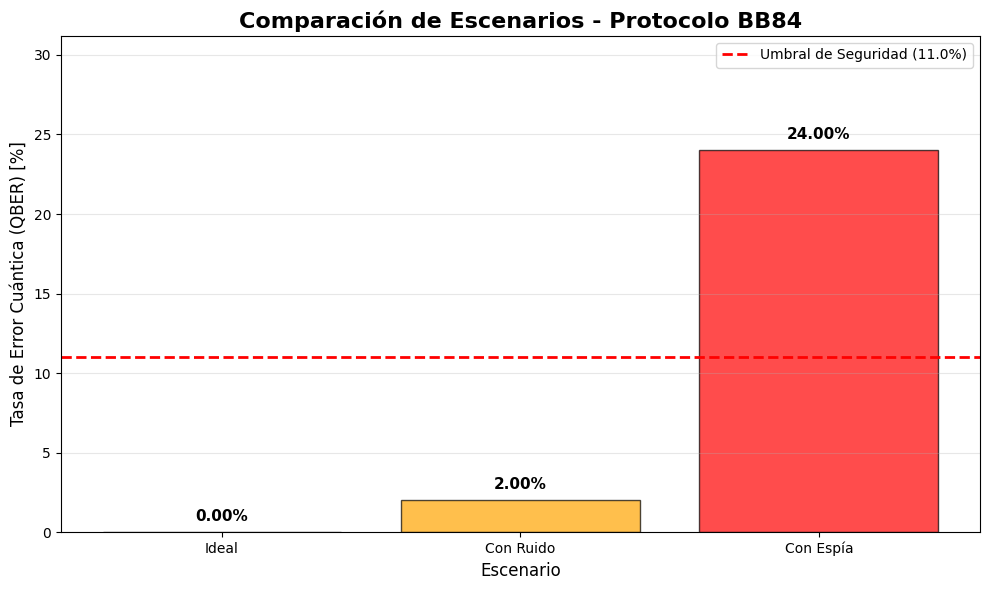

In [ ]:
plot_scenarios_comparison(resultados_globales)


### 10.2 Probabilidad de Detección de Espía


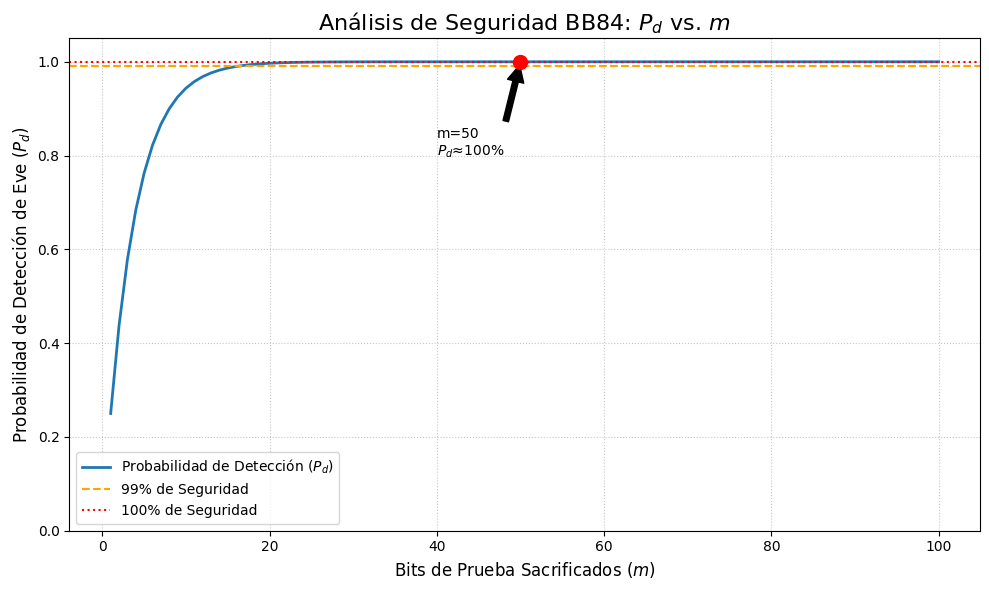

In [ ]:
plot_detection_probability()


### 10.3 Análisis de Sensibilidad al Ruido

Análisis detallado del impacto de cada tipo de ruido cuántico en el QBER.



📊 Analizando impacto de cada tipo de ruido...
  Depolarizing: QBER = 6.00%
  Phase Damping: QBER = 0.00%
  Amplitude Damping: QBER = 4.00%
  Readout: QBER = 2.00%
  Canal Clásico: QBER = 5.15%
  Mixto: QBER = 4.00%


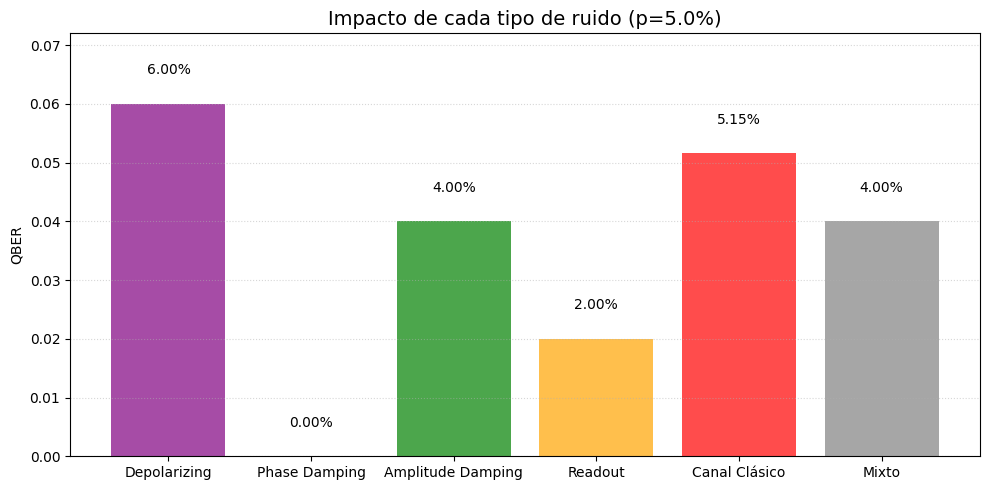

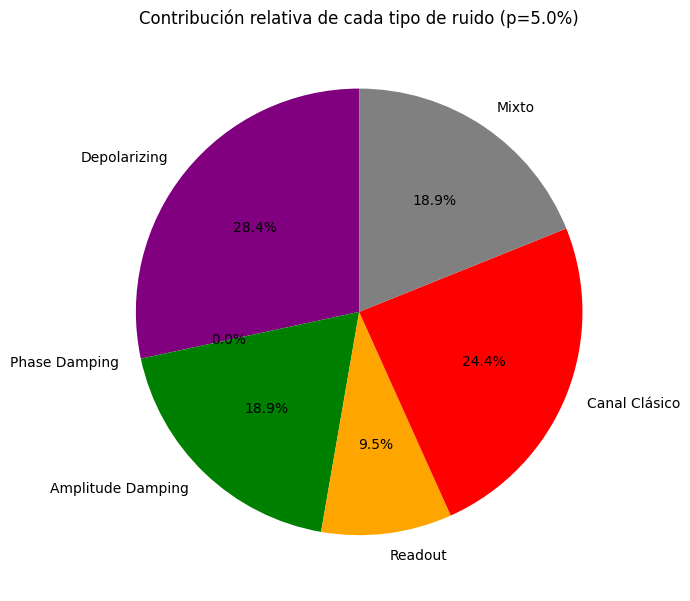


 Analizando crecimiento del QBER vs intensidad del ruido...



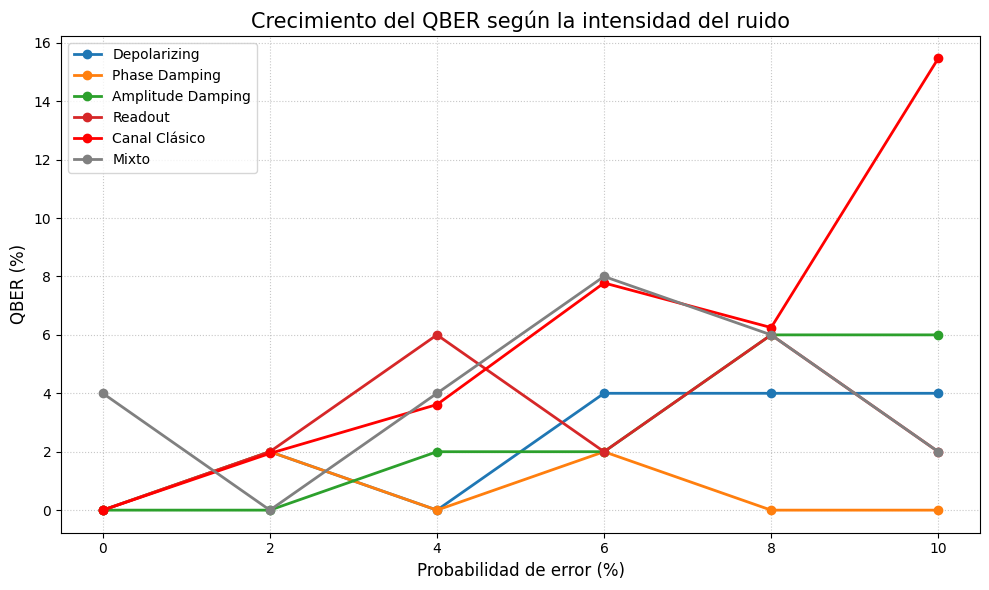

✓ Análisis completo de ruido cuántico, clásico y mixto generado.


In [ ]:

N_QUBITS = 200
TEST_SIZE = 50
np.random.seed(42)

def encode_qubit(bit, base):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if base == 1:
        qc.h(0)
    return qc

def measure_qubit(qc, base):
    if base == 1:
        qc.h(0)
    qc.measure(0, 0)
    return qc

def generar_bases_bob(n):
    return np.random.randint(2, size=n)

def generar_datos_alice(n):
    return np.random.randint(2, size=n), np.random.randint(2, size=n)

def codificar_qubits(bits, bases):
    return [encode_qubit(bits[i], bases[i]) for i in range(len(bits))]

def canal_clasico_con_ruido(bits, p_error_classic):
    """Simula errores clásicos (bit flips) en un canal clásico."""
    flips = np.random.rand(len(bits)) < p_error_classic
    return np.bitwise_xor(bits, flips.astype(int))

def medir_qber_con_ruido(tipo_error, prob_error, incluir_clasico=False, p_clasico=0.02):
    """
    Ejecuta BB84 con un tipo de ruido cuántico (y opcionalmente ruido clásico).
    """
    noise_model = NoiseModel()

    if tipo_error == 'Depolarizing':
        err = depolarizing_error(prob_error, 1)
        noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h'])
    elif tipo_error == 'Phase Damping':
        err = phase_damping_error(prob_error)
        noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h'])
    elif tipo_error == 'Amplitude Damping':
        err = amplitude_damping_error(prob_error)
        noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h'])
    elif tipo_error == 'Readout':
        err = ReadoutError([[1 - prob_error, prob_error],
                            [prob_error, 1 - prob_error]])
        noise_model.add_all_qubit_readout_error(err)
    elif tipo_error == 'Canal Clásico':
        bases_alice = np.random.randint(2, size=N_QUBITS)
        bases_bob = np.random.randint(2, size=N_QUBITS)
        bits_alice = np.random.randint(2, size=N_QUBITS)
        bases_bob_err = canal_clasico_con_ruido(bases_bob, prob_error)
        coincidencias = bases_alice == bases_bob_err
        if coincidencias.sum() == 0:
            return np.nan
        bits_bob = bits_alice.copy()
        errores = np.random.rand(coincidencias.sum()) < prob_error
        bits_bob[coincidencias] = np.bitwise_xor(bits_alice[coincidencias], errores.astype(int))
        qber = np.mean(bits_alice[coincidencias] != bits_bob[coincidencias])
        return qber
    else:
        raise ValueError("Tipo de error no reconocido")

    backend = AerSimulator(noise_model=noise_model)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    sampler = Sampler(mode=backend)

    bits_alice, bases_alice = generar_datos_alice(N_QUBITS)
    bases_bob = generar_bases_bob(N_QUBITS)
    circuitos = codificar_qubits(bits_alice, bases_alice)

    for i in range(N_QUBITS):
        circuitos[i] = measure_qubit(circuitos[i], bases_bob[i])

    circuits_isa = pm.run(circuitos)
    job = sampler.run(circuits_isa, shots=1)
    result = job.result()
    bits_bob = np.array([int(list(pub.data.c.get_counts().keys())[0]) for pub in result])

    if incluir_clasico:
        bases_bob = canal_clasico_con_ruido(bases_bob, p_clasico)

    indices = np.where(bases_alice == bases_bob)[0]
    if len(indices) == 0:
        return np.nan
    sifted_a, sifted_b = bits_alice[indices], bits_bob[indices]
    sample_size = min(TEST_SIZE, len(sifted_a))
    qber = np.sum(sifted_a[:sample_size] != sifted_b[:sample_size]) / sample_size
    return qber


errores = ['Depolarizing', 'Phase Damping', 'Amplitude Damping', 'Readout', 'Canal Clásico', 'Mixto']
prob_fija = 0.05
qber_por_error = []

print("\n📊 Analizando impacto de cada tipo de ruido...")

for tipo in errores:
    if tipo == 'Mixto':
        q = medir_qber_con_ruido('Depolarizing', prob_fija, incluir_clasico=True, p_clasico=0.02)
    else:
        q = medir_qber_con_ruido(tipo, prob_fija)
    qber_por_error.append(q)
    print(f"  {tipo}: QBER = {q:.2%}")

plt.figure(figsize=(10, 5))
plt.bar(errores, qber_por_error, color=['purple','blue','green','orange','red','gray'], alpha=0.7)
plt.title(f'Impacto de cada tipo de ruido (p={prob_fija*100}%)', fontsize=14)
plt.ylabel('QBER')
plt.ylim(0, max([x for x in qber_por_error if not np.isnan(x)]) * 1.2)
for i, q in enumerate(qber_por_error):
    if not np.isnan(q):
        plt.text(i, q + 0.005, f"{q:.2%}", ha='center', fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

qber_validos = [q for q in qber_por_error if not np.isnan(q)]
errores_validos = [e for e, q in zip(errores, qber_por_error) if not np.isnan(q)]

if len(qber_validos) > 0:
    plt.figure(figsize=(7, 7))
    plt.pie(qber_validos, labels=errores_validos, autopct='%1.1f%%',
            startangle=90, colors=['purple','blue','green','orange','red','gray'][:len(qber_validos)])
    plt.title(f'Contribución relativa de cada tipo de ruido (p={prob_fija*100}%)', fontsize=12)
    plt.tight_layout()
    plt.show()

print("\n Analizando crecimiento del QBER vs intensidad del ruido...\n")
probabilidades = np.linspace(0.0, 0.1, 6)

plt.figure(figsize=(10, 6))
for tipo in ['Depolarizing', 'Phase Damping', 'Amplitude Damping', 'Readout']:
    qbers = [medir_qber_con_ruido(tipo, p) for p in probabilidades]
    plt.plot(probabilidades*100, np.array(qbers)*100, '-o', label=tipo, linewidth=2)

qbers_classic = [medir_qber_con_ruido('Canal Clásico', p) for p in probabilidades]
qbers_mixed = [medir_qber_con_ruido('Depolarizing', p, incluir_clasico=True, p_clasico=0.02) for p in probabilidades]

plt.plot(probabilidades*100, np.array(qbers_classic)*100, '-o', label='Canal Clásico', color='red', linewidth=2)
plt.plot(probabilidades*100, np.array(qbers_mixed)*100, '-o', label='Mixto', color='gray', linewidth=2)

plt.title('Crecimiento del QBER según la intensidad del ruido', fontsize=15)
plt.xlabel('Probabilidad de error (%)', fontsize=12)
plt.ylabel('QBER (%)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("✓ Análisis completo de ruido cuántico, clásico y mixto generado.")

### 10.4 Correción de Errores
Gráfico de ejemplo de la efectividad de la corrección de errores mediante Cascade y amplificación de la privacidad.


--- GRÁFICO: EFECTIVIDAD DE LA CORRECCIÓN DE ERRORES ---


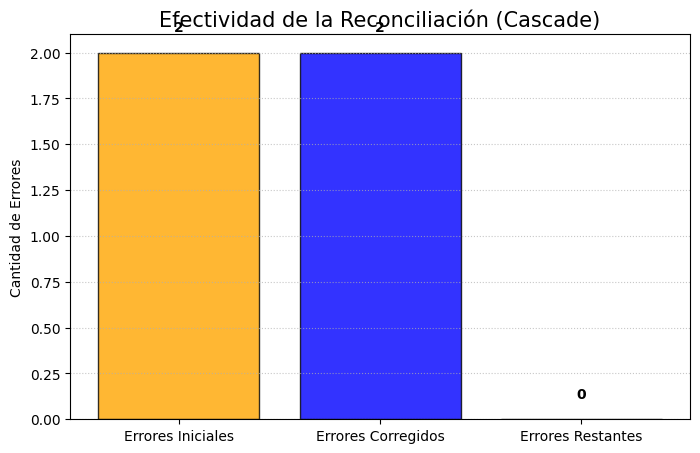

In [ ]:
print("\n--- GRÁFICO: EFECTIVIDAD DE LA CORRECCIÓN DE ERRORES ---")

sim_object = bb84_noisy

errors_iniciales = sim_object.errors_iniciales
total_corregidos = sim_object.total_corregidos
errors_restantes = sim_object.errors_restantes

if errors_iniciales != -1:
    labels = ['Errores Iniciales', 'Errores Corregidos', 'Errores Restantes']
    valores = [errors_iniciales, total_corregidos, errors_restantes]
    colores = ['orange', 'blue', 'red']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, valores, color=colores, alpha=0.8, edgecolor='black')

    if sim_object.use_cascade:
        plt.title('Efectividad de la Reconciliación (Cascade)', fontsize=15)
    else:
        plt.title('Efectividad de la Reconciliación (Descarte)', fontsize=15)

    plt.ylabel('Cantidad de Errores')
    plt.grid(axis='y', linestyle=':', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, int(yval), ha='center', va='bottom', fontweight='bold')

    plt.show()
else:
    print("No se ejecutó la reconciliación (QBER fue muy alto o no se habilitó).")


### Análisis de los diferentes tipos de ruido en el protocolo BB84

En el protocolo BB84, distintos tipos de ruido pueden afectar la fidelidad de la transmisión cuántica, incrementando la tasa de error (QBER). Cada canal representa un proceso físico diferente que altera el estado del qubit antes o durante la medición.

**Depolarizing noise**  
Modela errores completamente aleatorios: con probabilidad *p*, el estado se reemplaza por el estado mezclado $ I/2 $.
$$
\mathcal{E}_{dep}(\rho) = (1 - p)\rho + \tfrac{p}{3}(X\rho X + Y\rho Y + Z\rho Z)
$$
Este canal “empuja” al qubit hacia el centro de la esfera de Bloch, destruyendo la información de fase y amplitud, lo que suele aumentar directamente el QBER. Es el ruido más general y aleatorio, ya que introduce componentes no deseadas en todas las direcciones del espacio de Bloch.

**Amplitude damping**  
Representa la pérdida de energía del qubit, por ejemplo cuando $|1\rangle$ decae a $|0\rangle$.
$$
\mathcal{E}_{amp}(\rho) = E_0\rho E_0^\dagger + E_1\rho E_1^\dagger
$$
Solo afecta los estados con componente $|1\rangle$, por lo que puede no alterar el QBER si la mayoría de los qubits se preparan y miden en la base computacional (Z). En esos casos, aunque el estado físico se degrade, las mediciones pueden seguir coincidiendo entre Alice y Bob.

**Phase damping**  
Reduce la coherencia entre $|0\rangle$ y $|1\rangle$ sin cambiar sus probabilidades.
$$
\mathcal{E}_{phase}(\rho) = E_0\rho E_0^\dagger + E_1\rho E_1^\dagger
$$
Destruye la fase relativa, pero no modifica las mediciones en la base Z, por lo que el QBER puede permanecer cercano a cero. Su efecto se nota más si los qubits se miden en la base X, donde la pérdida de coherencia afecta los resultados.

**Readout noise**  
No afecta al estado cuántico en sí, sino al proceso de medición: con probabilidad *p*, el bit medido se invierte (0→1 o 1→0).
$$
P =
\begin{pmatrix}
1-p & p \\
p & 1-p
\end{pmatrix}
$$
Este tipo de ruido suele producir los valores de QBER más altos, ya que altera directamente los bits finales sin depender del estado ni de la base usada. Es el único que actúa en el dominio clásico, sobre los resultados medidos.

**Ruido clásico**  
Afecta la comunicación pública de las bases entre Alice y Bob. Se modela como un *bit flip* aleatorio con probabilidad $p_c$:
$$
\text{bases}_B' = \text{bases}_B \oplus \text{error}(p_c)
$$
Provoca desacuerdos entre las bases y reduce la longitud de la clave filtrada, incrementando el QBER si el canal clásico es ruidoso. Este tipo de error no altera los estados cuánticos, pero afecta la coincidencia de las bases utilizadas para la medición.

**Canal mixto (cuántico + clásico)**  
Combina simultáneamente errores cuánticos (como depolarizing o readout) con perturbaciones en el canal clásico. En este caso, la degradación del estado cuántico se suma a los desacuerdos en la comunicación de las bases, generando una acumulación de errores. El QBER resultante crece más rápido con *p*, ya que ambos procesos actúan en etapas diferentes del protocolo.

### Interpretación de los resultados gráficos

En los gráficos generados, el QBER de los canales de *phase damping* y *amplitude damping* puede permanecer en cero incluso para probabilidades de error relativamente altas. Esto ocurre porque dichos ruidos degradan la coherencia del qubit, pero no necesariamente modifican las probabilidades de obtener 0 o 1 al medir en la base Z. En otras palabras, el estado se vuelve menos “cuántico”, pero las mediciones clásicas siguen dando los mismos resultados.

Por el contrario, el ruido *depolarizing* introduce errores en todas las direcciones del espacio de Bloch, afectando directamente la probabilidad de obtener el bit correcto, por lo que incrementa el QBER de forma visible y proporcional a *p*.

El *readout noise*, al actuar justo en la medición, es el más sensible: aunque el canal cuántico sea ideal, invertir un bit en la lectura impacta directamente en la clave final, lo que explica los picos altos del QBER incluso para valores pequeños de *p*.

Finalmente, los canales *clásico* y *mixto* confirman que el ruido no solo se origina en el hardware cuántico, sino también en la comunicación pública: los errores en la transmisión de bases o la combinación de ambos efectos pueden aumentar significativamente el QBER, reduciendo la eficiencia y seguridad del protocolo.

# Agregación de compuerta Identidad para el análisis de ruido en caso de que un qubit no pase por una compuerta


SCENARIO 1: SIN RUIDO
QBER = 0.00%

ESCENARIO 2: CON RUIDO BASE (con 'id')
✓ Modelo de ruido base (con 'id') configurado:
  Amplitude damping: 1.00% | Depolarizing: 1.50% | Readout: 5.00%
QBER = 8.00%

ESCENARIO 3: CON MODELO COMPLETO (con 'id' + 'cx')
Modelo de ruido completo configurado:
  • 1Q gates (['u1', 'u2', 'u3', 'x', 'h', 'id']) → amplitude, phase, depolarizing
  • 2Q gates (['cx']) → depolarizing
  • Readout: 5.00%
QBER = 10.00%

RESULTADOS GLOBALES:
Ideal: 0.00% | Base: 8.00% | Completo: 10.00%
QBER = 2.00%
QBER = 0.00%
QBER = 2.00%


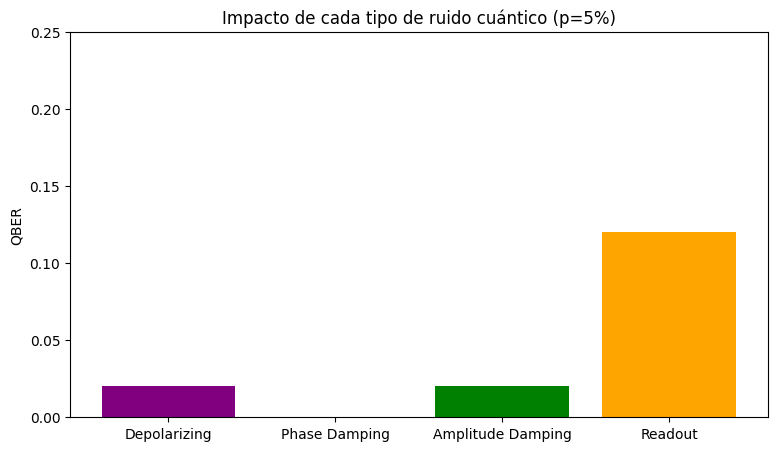

QBER = 0.00%
QBER = 0.00%
QBER = 2.00%
QBER = 4.00%
QBER = 6.00%
QBER = 10.00%
QBER = 0.00%
QBER = 0.00%
QBER = 0.00%
QBER = 0.00%
QBER = 0.00%
QBER = 0.00%
QBER = 0.00%
QBER = 2.00%
QBER = 0.00%
QBER = 6.00%
QBER = 4.00%
QBER = 8.00%


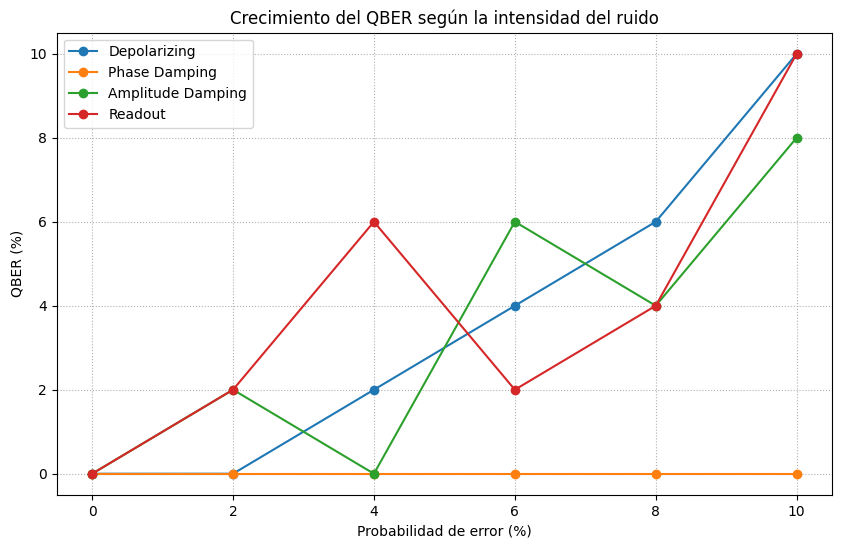

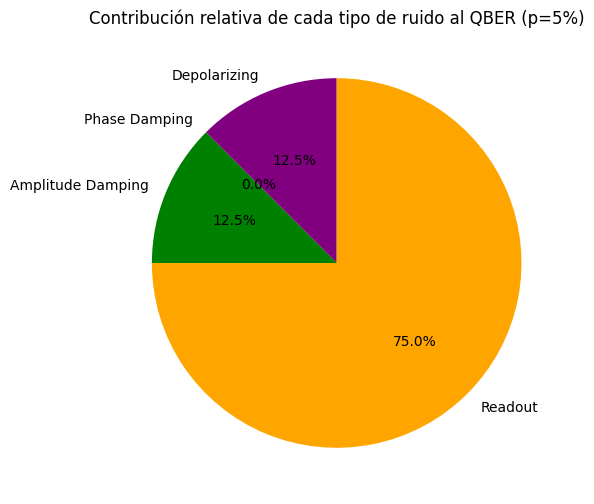

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, phase_damping_error, amplitude_damping_error, ReadoutError
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

N_QUBITS = 200
TEST_SIZE = 50
QBER_THRESHOLD = 0.11
BLOCK_SIZE = 4

np.random.seed(42)

def encode_qubit(bit, base):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if base == 1:
        qc.h(0)
    return qc

def measure_qubit(qc, base):
    if base == 1:
        qc.h(0)
    qc.measure(0, 0)
    return qc

def generar_bases_bob(n):
    return np.random.randint(2, size=n)

def generar_datos_alice(n):
    return np.random.randint(2, size=n), np.random.randint(2, size=n)

def codificar_qubits(bits, bases):
    return [encode_qubit(bits[i], bases[i]) for i in range(len(bits))]

def create_noise_model(p_amp=0.01, p_depol=0.015, p_readout=0.05):
    """
    Modelo base: incluye decoherencia en compuerta identidad ('id')
    """
    err_amp = amplitude_damping_error(p_amp)
    err_depol = depolarizing_error(p_depol, 1)
    combined_error = err_depol.compose(err_amp)
    err_read = ReadoutError([[1 - p_readout, p_readout],
                             [p_readout, 1 - p_readout]])

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(combined_error,
        ['u1', 'u2', 'u3', 'id', 'x', 'h'])
    noise_model.add_all_qubit_readout_error(err_read)

    print("✓ Modelo de ruido base (con 'id') configurado:")
    print(f"  Amplitude damping: {p_amp*100:.2f}% | Depolarizing: {p_depol*100:.2f}% | Readout: {p_readout*100:.2f}%")
    return noise_model

def create_noise_model_completo(p_amp=0.01, p_depol=0.015, p_phase=0.008, p_readout=0.05):
    """
    Modelo de ruido completo:
    - Aplica errores de 1 qubit a compuertas de 1 qubit (u1,u2,u3,x,h,id)
    - Aplica errores de 2 qubits a compuerta CX
    - Incluye error de lectura
    """
    noise_model = NoiseModel()

    err_amp_1q = amplitude_damping_error(p_amp)
    err_depol_1q = depolarizing_error(p_depol, 1)
    err_phase_1q = phase_damping_error(p_phase)
    combined_1q = err_depol_1q.compose(err_amp_1q).compose(err_phase_1q)

    err_depol_2q = depolarizing_error(p_depol, 2)

    err_read = ReadoutError([[1 - p_readout, p_readout],
                             [p_readout, 1 - p_readout]])

    one_qubit_gates = ['u1', 'u2', 'u3', 'x', 'h', 'id']
    two_qubit_gates = ['cx']

    noise_model.add_all_qubit_quantum_error(combined_1q, one_qubit_gates)
    noise_model.add_all_qubit_quantum_error(err_depol_2q, two_qubit_gates)
    noise_model.add_all_qubit_readout_error(err_read)

    print("Modelo de ruido completo configurado:")
    print(f"  • 1Q gates ({one_qubit_gates}) → amplitude, phase, depolarizing")
    print(f"  • 2Q gates ({two_qubit_gates}) → depolarizing")
    print(f"  • Readout: {p_readout*100:.2f}%")
    return noise_model

def canal_clasico_con_ruido(bits, p_error_classic):
    flips = np.random.rand(len(bits)) < p_error_classic
    return np.bitwise_xor(bits, flips.astype(int))

def sift_keys_con_ruido_clasico(bases_alice, bases_bob, bits_alice, bits_bob, p_error_classic):
    bases_bob_recibidas = canal_clasico_con_ruido(bases_bob, p_error_classic)
    sifted_a, sifted_b = [], []
    for i in range(len(bases_alice)):
        if bases_alice[i] == bases_bob_recibidas[i]:
            sifted_a.append(bits_alice[i])
            sifted_b.append(bits_bob[i])
    return np.array(sifted_a), np.array(sifted_b)

class BB84Protocol:
    def __init__(self, n_qubits=200, test_size=50, noise_model=None, enable_eve=False):
        self.n_qubits = n_qubits
        self.test_size = test_size
        self.enable_eve = enable_eve
        backend = AerSimulator(noise_model=noise_model) if noise_model else AerSimulator()
        self.backend = backend
        self.pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
        self.sampler = Sampler(mode=backend)

    def run_protocol(self):
        bits_alice, bases_alice = generar_datos_alice(self.n_qubits)
        bases_bob = generar_bases_bob(self.n_qubits)
        circuits = codificar_qubits(bits_alice, bases_alice)

        for i in range(self.n_qubits):
            circuits[i] = measure_qubit(circuits[i], bases_bob[i])

        circuits_isa = self.pm.run(circuits)
        job = self.sampler.run(circuits_isa, shots=1)
        result = job.result()
        bits_bob = np.array([int(list(pub.data.c.get_counts().keys())[0]) for pub in result])

        indices = np.where(bases_alice == bases_bob)[0]
        sifted_a, sifted_b = bits_alice[indices], bits_bob[indices]

        sample_size = min(self.test_size, len(sifted_a))
        errors = np.sum(sifted_a[:sample_size] != sifted_b[:sample_size])
        qber = errors / sample_size if sample_size > 0 else np.nan
        print(f"QBER = {qber:.2%}")
        return qber

def medir_qber_con_ruido(tipo_error, prob_error):
    noise_model = NoiseModel()
    if tipo_error == 'Depolarizing':
        err = depolarizing_error(prob_error, 1)
    elif tipo_error == 'Amplitude Damping':
        err = amplitude_damping_error(prob_error)
    elif tipo_error == 'Phase Damping':
        err = phase_damping_error(prob_error)
    elif tipo_error == 'Readout':
        err = ReadoutError([[1 - prob_error, prob_error], [prob_error, 1 - prob_error]])
        noise_model.add_all_qubit_readout_error(err)
        backend = AerSimulator(noise_model=noise_model)
        pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
        sampler = Sampler(mode=backend)
        bits_alice, bases_alice = generar_datos_alice(N_QUBITS)
        bases_bob = generar_bases_bob(N_QUBITS)
        circuits = codificar_qubits(bits_alice, bases_alice)
        for i in range(N_QUBITS):
            circuits[i] = measure_qubit(circuits[i], bases_bob[i])
        circuits_isa = pm.run(circuits)
        job = sampler.run(circuits_isa, shots=1)
        result = job.result()
        bits_bob = np.array([int(list(pub.data.c.get_counts().keys())[0]) for pub in result])
        indices = np.where(bases_alice == bases_bob)[0]
        sifted_a, sifted_b = bits_alice[indices], bits_bob[indices]
        sample_size = min(TEST_SIZE, len(sifted_a))
        qber = np.sum(sifted_a[:sample_size] != sifted_b[:sample_size]) / sample_size
        return qber
    noise_model.add_all_qubit_quantum_error(err, ['u1','u2','u3','x','h','id'])
    backend = AerSimulator(noise_model=noise_model)
    bb84 = BB84Protocol(n_qubits=N_QUBITS, test_size=TEST_SIZE, noise_model=noise_model)
    return bb84.run_protocol()

def llamar_modelos_diferente_ruido():
    errores = ['Depolarizing', 'Phase Damping', 'Amplitude Damping', 'Readout']
    probabilidades = np.linspace(0.0, 0.1, 6)
    prob_fija = 0.05

    qber_por_error = [medir_qber_con_ruido(tipo, prob_fija) for tipo in errores]
    plt.figure(figsize=(9,5))
    plt.bar(errores, qber_por_error, color=['purple','blue','green','orange'])
    plt.title('Impacto de cada tipo de ruido cuántico (p=5%)')
    plt.ylabel('QBER')
    plt.ylim(0, 0.25)
    plt.show()

    plt.figure(figsize=(10,6))
    for tipo in errores:
        qbers = [medir_qber_con_ruido(tipo, p) for p in probabilidades]
        plt.plot(probabilidades*100, np.array(qbers)*100, '-o', label=tipo)
    plt.title('Crecimiento del QBER según la intensidad del ruido')
    plt.xlabel('Probabilidad de error (%)')
    plt.ylabel('QBER (%)')
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.show()

    plt.figure(figsize=(6,6))
    plt.pie(qber_por_error, labels=errores, autopct='%1.1f%%',
            startangle=90, colors=['purple','blue','green','orange'])
    plt.title('Contribución relativa de cada tipo de ruido al QBER (p=5%)')
    plt.show()

if __name__ == "__main__":
    print("\nSCENARIO 1: SIN RUIDO")
    bb84_ideal = BB84Protocol(n_qubits=N_QUBITS, test_size=TEST_SIZE)
    qber_ideal = bb84_ideal.run_protocol()

    print("\nESCENARIO 2: CON RUIDO BASE (con 'id')")
    noise_model = create_noise_model()
    bb84_noisy = BB84Protocol(n_qubits=N_QUBITS, test_size=TEST_SIZE, noise_model=noise_model)
    qber_noisy = bb84_noisy.run_protocol()

    print("\nESCENARIO 3: CON MODELO COMPLETO (con 'id' + 'cx')")
    noise_full = create_noise_model_completo()
    bb84_full = BB84Protocol(n_qubits=N_QUBITS, test_size=TEST_SIZE, noise_model=noise_full)
    qber_full = bb84_full.run_protocol()

    print("\nRESULTADOS GLOBALES:")
    print(f"Ideal: {qber_ideal*100:.2f}% | Base: {qber_noisy*100:.2f}% | Completo: {qber_full*100:.2f}%")

    llamar_modelos_diferente_ruido()

En un dispositivo cuántico real, los qubits no solo se degradan cuando se aplican compuertas lógicas activas, sino también cuando permanecen inactivos durante un cierto tiempo (por ejemplo, mientras otros qubits están siendo operados o medidos). Esa degradación espontánea se conoce como decoherencia pasiva.

En teoría, la compuerta 'id' en Qiskit no introduce ningún cambio en el estado del qubit, es simplemente la aplicación explícita de la matriz identidad. Por tanto, por sí sola, no modela un retardo temporal ni una fuente de ruido.

Sin embargo, al asociarle un modelo de error (por ejemplo, un canal de depolarizing, amplitude damping o phase damping), podemos forzar al simulador a aplicar esos errores cada vez que aparece una id en el circuito.

Al aplicar estos modelos de error sobre la compuerta id, lo que se busca es que el simulador reproduzca el comportamiento del hardware real, donde los qubits se degradan con el tiempo incluso si no se están operando. De este modo, la id funciona como un marcador artificial de “reposo” que permite inyectar ruido durante los intervalos en los que el qubit estaría inactivo.

No obstante, el impacto de estos errores sobre el QBER depende fuertemente del tipo de estado transmitido y de las bases elegidas por Alice y Bob. En muchos casos, los errores de phase damping o amplitude damping no producen una variación visible en el QBER, ya que afectan principalmente la coherencia o la amplitud del estado, pero no necesariamente modifican el resultado de la medición cuando se trabaja en la base computacional (Z). Por eso, aun cuando el circuito esté sometido a ruido, las mediciones pueden coincidir y el QBER permanecer cercano a cero.

En cambio, los errores de depolarizing o de readout suelen generar incrementos más notorios del QBER. El primero introduce una aleatoriedad completa en el estado cuántico, rompiendo la correlación entre Alice y Bob; el segundo actúa en el proceso de medición y altera directamente los bits finales, afectando la clave sin depender de la base o del estado inicial.

En síntesis, la incorporación de la compuerta id dentro del modelo de ruido no representa un nuevo tipo de operación cuántica, sino una forma de hacer que el simulador considere los efectos inevitables de la decoherencia pasiva. Esto permite obtener un comportamiento más realista, reflejando que incluso los qubits “en reposo” están expuestos a los mecanismos de ruido del hardware.

Optimization level en este caso se mantuvo en 0 dado que si no se ignoraban las puertas id, dejando sin sentido el análisis de la simulación.

# Análisis de Protocolos QKD y Contexto Poscuántico

A continuación, se presenta un análisis de los fundamentos de la Distribución Cuántica de Claves (QKD) y su contexto dentro del panorama más amplio de la criptografía poscuántica.

---

## 1. El Dilema Cuántico: ¿Por Qué Necesitamos QKD?

La seguridad de nuestra infraestructura digital actual, como el sistema **RSA** o la Criptografía de Curva Elíptica (ECC), se basa en la **dificultad computacional**. Confiamos en que a las computadoras clásicas les tomaría miles de años factorizar los números semiprimos muy grandes que protegen nuestras claves públicas.

El problema, como se menciona en la consigna de la hackathon, es que la computación cuántica amenaza este paradigma. Un algoritmo cuántico como el de **Shor** está diseñado específicamente para resolver la factorización en tiempo polinomial, volviendo obsoletos muchos de nuestros métodos de cifrado actuales.

Esto nos obliga a buscar nuevas formas de proteger la información, lo que nos lleva a dos caminos principales: la Criptografía Poscuántica (PQC) y la Distribución Cuántica de Claves (QKD).

---

## 2. Contexto: QKD vs. Criptografía Poscuántica (PQC)

Es fundamental no confundir estos dos enfoques:

* **Criptografía Poscuántica (PQC):** Son algoritmos **100% clásicos** (software que corre en nuestras computadoras actuales) diseñados para ser resistentes a ataques de computadoras cuánticas. Se basan en problemas matemáticos que creemos que *ni siquiera* las computadoras cuánticas pueden resolver eficientemente (como la criptografía basada en retículos).

* **Distribución Cuántica de Claves (QKD):** Es un protocolo de **hardware cuántico**. No es un nuevo tipo de cifrado, sino un método para **distribuir de forma segura una clave secreta** (una clave simétrica). Su seguridad no se basa en la dificultad matemática, sino en las **leyes fundamentales de la física**.

---

## 3. Comparativa de Protocolos QKD: BB84 vs. E91

Como solicitó el *prompt*, comparamos nuestro protocolo implementado (BB84) con un enfoque emergente (E91) para entender cómo resisten los ataques.

## Protocolo BB84 (Preparar y Enviar)

* **Fundamento:** Como vimos en la Clase 4, Alice **prepara y envía** qubits individuales (fotones) en una de dos bases elegidas al azar.
    * **Base Z (Computacional):**
        \begin{equation}
        \{|0\rangle, |1\rangle\}
        \end{equation}
    * **Base X (Hadamard):**
        \begin{equation}
        \{|+\rangle, |-\rangle\}
        \end{equation}
    Bob mide también en una de esas dos bases elegidas al azar.

* **Resistencia a Ataques (Colapso de Medición):** La seguridad de BB84 proviene del **Principio de Incertidumbre** y el colapso del estado cuántico. Si un espía (Eve) intercepta un qubit, no sabe en qué base fue preparado.
    * Si Alice envía $|+\rangle$ (Base X) y Eve mide en la Base Z, el estado colapsa aleatoriamente a $|0\rangle$ o $|1\rangle$.
    * Eve luego reenvía este estado colapsado a Bob.
    * Incluso si Bob mide en la base correcta (Base X), ahora recibirá un $|0\rangle$ o $|1\rangle$, que en la Base X es una superposición 50/50 de $|+\rangle$ y $|-\rangle$.
    * **Resultado:** La intrusión de Eve introduce **errores detectables**. Alice y Bob detectan a Eve al sacrificar y comparar públicamente una muestra de su clave. Como vimos en nuestra simulación (y como predice la teoría), la Tasa de Error de Bits Cuánticos (QBER) es $\approx 25\%$, lo que delata al espía.

### Protocolo E91 (Basado en Entrelazamiento)

El protocolo E91, propuesto por Artur Ekert en 1991, es un método de QKD radicalmente diferente. Su genialidad reside en que **transforma la seguridad criptográfica en una prueba de física fundamental**.

En lugar de "esperar" que Eve (la espía) introduzca errores al medir (como en BB84), el protocolo E91 le dice a Alice y Bob: "No confíen en nadie. Ni siquiera en la fuente que les envía los qubits. Hagan un experimento para *probar* que sus qubits están perfectamente entrelazados. Si lo están, pueden estar 100% seguros de que nadie los espió".

#### 1. El Fundamento E91: El Estado EPR

El protocolo E91 comienza con una fuente que distribuye un par de qubits entrelazados, uno para Alice (A) y otro para Bob (B). Estos qubits están en un estado de Bell, típicamente el estado que usamos en nuestras simulaciones:

\begin{equation}
|\Phi^+\rangle_{AB} = \frac{1}{\sqrt{2}}(|0\rangle_A \otimes |0\rangle_B + |1\rangle_A \otimes |1\rangle_B)
\end{equation}

Este estado es la base de todo el protocolo. Matemáticamente, es un vector en un espacio de Hilbert de 4 dimensiones ($2 \times 2$) que no puede ser factorizado en dos vectores de 1 qubit.

#### 2. Medición E91: Los Observables

Alice y Bob miden sus qubits usando un conjunto de observables (operadores hermíticos). Para realizar el Test de Bell (CHSH), se requiere un conjunto específico de 2 bases para Alice y 2 para Bob.

* **Alice** elige aleatoriamente entre dos observables, $A_1$ y $A_2$.
* **Bob** elige aleatoriamente entre dos observables, $B_1$ y $B_2$.

Estos observables son operadores con autovalores $\lambda = \pm 1$. Los ángulos de medición se eligen específicamente para maximizar la violación de la desigualdad de Bell. Un conjunto óptimo es:

* **Alice:**
    * $A_1 = \hat{Z}_A$ (Medir en la base Z, 0°)
    * $A_2 = \hat{X}_A$ (Medir en la base X, 90°)
* **Bob:**
    * $B_1 = \frac{1}{\sqrt{2}}(\hat{Z}_B + \hat{X}_B)$ (Medir en 45°)
    * $B_2 = \frac{1}{\sqrt{2}}(\hat{Z}_B - \hat{X}_B)$ (Medir en 135°)

Alice y Bob realizan $N$ mediciones, generando dos listas de resultados $a_i$ y $b_i$, donde cada resultado es $+1$ o $-1$.

#### 3. Conversación Clásica y Separación de Datos

Tras medir todos los qubits, Alice y Bob anuncian *públicamente* la secuencia de bases (observables) que usaron para cada medición $i$. Luego, dividen sus $N$ resultados en dos grupos:

* **Clave Secreta ($K$):** Toman todos los bits $i$ donde, por casualidad, ambos usaron la misma base (ej. $A_1$ y $B_1$, aunque en la práctica se usan bases rectilíneas como Z y X para esto). Dado que sus mediciones del par $|\Phi^+\rangle$ en la misma base (Z o X) están perfectamente correlacionadas, sus listas de bits $a_i$ y $b_i$ para este grupo deberían ser idénticas.
* **Muestra de Seguridad ($S$):** Toman todos los bits $i$ donde usaron **bases diferentes** (ej. Alice usó $A_1$ y Bob usó $B_2$). Estos resultados se anuncian públicamente y se usan para el test.

#### 4. El Veredicto: Cálculo del Valor $S$

Este es el núcleo matemático. Alice y Bob calculan la **función de correlación** (o valor esperado) $E(A, B)$ para cada una de las 4 combinaciones de bases.

Teóricamente, este valor es:
\begin{equation}
E(A, B) = \langle \hat{A} \otimes \hat{B} \rangle = \langle\Phi^+| (\hat{A} \otimes \hat{B}) |\Phi^+\rangle
\end{equation}
Experimentalmente, ellos lo calculan como el promedio de sus bits (con $\pm 1$):
\begin{equation}
E(A, B) \approx \frac{1}{N_{\text{rondas}}} \sum_{i} a_i \cdot b_i
\end{equation}
La desigualdad de Bell, en la forma CHSH, establece un límite a la combinación de estas correlaciones para cualquier teoría "clásica" o de "variables ocultas":
\begin{equation}
S = |E(A_1, B_1) + E(A_1, B_2) + E(A_2, B_1) - E(A_2, B_2)| \le 2
\end{equation}
Si el canal es seguro y el estado es el $|\Phi^+\rangle$ puro, la mecánica cuántica predice (para los ángulos óptimos) un valor máximo de:
\begin{equation}
S_{\text{cuántico}} = 2\sqrt{2} \approx 2.82
\end{equation}
Como **$S_{\text{cuántico}} > 2$**, el entrelazamiento "viola" la desigualdad de Bell.

* **Veredicto (Canal Seguro):** Alice y Bob calculan $S \approx 2.82$. Esto prueba que el entrelazamiento está intacto y que nadie ha espiado.
* **Veredicto (Canal Inseguro):** Si obtienen $S \le 2$, saben que la correlación es clásica.

#### 5. Resistencia a Ataques (La Matemática de Eve)

Si Eve intercepta y mide el qubit de Bob, **rompe el entrelazamiento**. El estado puro $|\Phi^+\rangle$ colapsa. El sistema que comparten Alice y Bob ya no es un estado entrelazado, sino una **mezcla estadística** (un estado mixto) de los posibles resultados de Eve.

Por ejemplo, si Eve mide en la base Z, el estado se convierte en:
\begin{equation}
\rho_{\text{Eve}} = \frac{1}{2}\Big( |0\rangle_A\langle 0| \otimes |0\rangle_B\langle 0| + |1\rangle_A\langle 1| \otimes |1\rangle_B\langle 1| \Big)
\end{equation}
Este estado $\rho_{\text{Eve}}$ **representa un sistema clásico** (es separable y tiene "variables ocultas": el resultado de la medición de Eve). Cuando Alice y Bob calculan el valor $S$ para *este* estado, la matemática garantiza que **$S \le 2$**.

Por lo tanto, cualquier intento de Eve de interceptar y medir se manifiesta como la *pérdida de la violación de Bell*. El protocolo es seguro porque la seguridad es **demostrable** por los propios usuarios.

---

## 4. Conclusión: Seguridad Basada en la Física

Ambos protocolos logran el mismo objetivo —la distribución segura de una clave— pero con fundamentos cuánticos distintos. Resisten los ataques cuánticos porque **utilizan las propiedades cuánticas como su propio sistema de alarma**.

A diferencia de RSA (que será vulnerable a un ataque cuántico), la seguridad de QKD no se basa en el poder computacional del atacante. Eve no puede ser "más inteligente" que las leyes de la física. No puede violar el Teorema de No Clonación para copiar el qubit, y no puede medirlo (ya sea en BB84 o E91) sin dejar una huella detectable. Esto proporciona una **seguridad basada en la información** para el futuro poscuántico.

In [ ]:
# Configuración del simulador para E91
aer_sim_e91 = AerSimulator()
pm_e91 = generate_preset_pass_manager(backend=aer_sim_e91, optimization_level=1)
sampler_e91 = Sampler(mode=aer_sim_e91)

print("✓ Simulador E91 configurado")

✓ Simulador E91 configurado


In [ ]:
def create_epr_pair():
    """
    Crea un par de qubits entrelazados en el estado de Bell |Φ⁺⟩.

    El estado |Φ⁺⟩ = (1/√2)(|00⟩ + |11⟩) es máximamente entrelazado
    y perfectamente correlacionado cuando se mide en la misma base.

    Returns:
        QuantumCircuit: Circuito con el par EPR preparado
    """
    qc = QuantumCircuit(2, 2)
    qc.h(0)      # Superposición en el primer qubit
    qc.cx(0, 1)  # Entrelazamiento con CNOT
    return qc


def create_chsh_circuits(with_entanglement=True):
    """
    Crea los 4 circuitos necesarios para el test CHSH.

    Test CHSH: Mide correlaciones cuánticas usando 4 combinaciones
    de bases de medición (2 para Alice, 2 para Bob).

    Ángulos óptimos:
    - Alice: A₁ = 0° (base Z), A₂ = 90° (base X)
    - Bob:   B₁ = 45°, B₂ = 135°

    Args:
        with_entanglement (bool): Si True, usa estado entrelazado |Φ⁺⟩.
                                  Si False, usa estado separable |+0⟩

    Returns:
        list: Lista de 4 QuantumCircuit para las combinaciones:
              [A₁B₁, A₁B₂, A₂B₁, A₂B₂]
    """
    circuits = []

    # Definir las bases de medición como funciones
    # Alice: a1=0° (Z), a2=90° (X)
    bases_alice = [
        lambda qc: None,      # A₁: Base Z (identidad)
        lambda qc: None,      # A₁: Base Z
        lambda qc: qc.h(0),   # A₂: Base X (Hadamard)
        lambda qc: qc.h(0)    # A₂: Base X
    ]

    # Bob: b1=45°, b2=135°
    bases_bob = [
        lambda qc: qc.ry(-np.pi/4, 1),      # B₁: 45°
        lambda qc: qc.ry(-3*np.pi/4, 1),    # B₂: 135°
        lambda qc: qc.ry(-np.pi/4, 1),      # B₁: 45°
        lambda qc: qc.ry(-3*np.pi/4, 1)     # B₂: 135°
    ]

    for apply_alice, apply_bob in zip(bases_alice, bases_bob):
        if with_entanglement:
            qc = create_epr_pair()
        else:
            # Estado separable (simula ataque de Eve)
            qc = QuantumCircuit(2, 2)
            qc.h(0)  # |+0⟩ - NO entrelazado

        qc.barrier()

        # Aplicar rotaciones de medición
        if apply_alice is not None:
            apply_alice(qc)
        if apply_bob is not None:
            apply_bob(qc)

        qc.measure([0, 1], [0, 1])
        circuits.append(qc)

    return circuits


def calculate_expectation_value(counts, shots):
    """
    Calcula el valor esperado E = P(igual) - P(diferente).

    Para correlaciones cuánticas:
    - P(igual) = P(00) + P(11): ambos miden lo mismo
    - P(diferente) = P(01) + P(10): miden diferente

    Args:
        counts (dict): Diccionario de conteos {'00': n1, '01': n2, ...}
        shots (int): Número total de mediciones

    Returns:
        float: Valor esperado E ∈ [-1, 1]
    """
    p_igual = (counts.get('00', 0) + counts.get('11', 0)) / shots
    p_diferente = (counts.get('01', 0) + counts.get('10', 0)) / shots
    return p_igual - p_diferente


def run_chsh_test(circuits, pm, sampler_inst, shots=4096):
    """
    Ejecuta el test CHSH completo y calcula el valor S.

    Desigualdad CHSH clásica: S ≤ 2
    Límite cuántico (Tsirelson): S ≤ 2√2 ≈ 2.828

    Args:
        circuits (list): 4 circuitos CHSH
        pm (PassManager): Pass manager para transpilación
        sampler_inst (Sampler): Sampler para ejecución
        shots (int): Número de mediciones por circuito

    Returns:
        tuple: (S_value, E_values)
            - S_value: Parámetro CHSH
            - E_values: Lista de 4 valores esperados [E(A₁,B₁), ...]
    """
    circuits_isa = pm.run(circuits)
    job = sampler_inst.run(circuits_isa, shots=shots)
    result = job.result()

    E_values = []
    for pub_result in result:
        counts = pub_result.data.c.get_counts()
        E_val = calculate_expectation_value(counts, shots)
        E_values.append(E_val)

    # Fórmula CHSH: S = |E(A₁,B₁) + E(A₁,B₂) + E(A₂,B₁) - E(A₂,B₂)|
    S_value = abs(E_values[0] + E_values[1] + E_values[2] - E_values[3])

    return S_value, E_values

In [ ]:
print("="*70)
print("PROTOCOLO E91: TEST CHSH".center(70))
print("="*70)

# Escenario 1: Canal Seguro (con entrelazamiento)
print("\n🔵 Escenario 1: CANAL SEGURO (Estado entrelazado)")
print("-" * 70)

circuits_secure = create_chsh_circuits(with_entanglement=True)
S_secure, E_secure = run_chsh_test(circuits_secure, pm_e91, sampler_e91)

print(f"Valores esperados E:")
print(f"  E(A₁,B₁) = {E_secure[0]:.4f}")
print(f"  E(A₁,B₂) = {E_secure[1]:.4f}")
print(f"  E(A₂,B₁) = {E_secure[2]:.4f}")
print(f"  E(A₂,B₂) = {E_secure[3]:.4f}")
print(f"\n📊 Parámetro CHSH: S = {S_secure:.4f}")
print(f"   Límite clásico: S ≤ 2.0000")
print(f"   Límite cuántico (Tsirelson): S ≤ 2.8284")

if S_secure > 2:
    print(f"\n✅ VEREDICTO: S > 2 → ¡Violación de Bell!")
    print(f"   El estado está entrelazado → CANAL SEGURO")
else:
    print(f"\n⚠️  VEREDICTO: S ≤ 2 → Sin violación de Bell")
    print(f"   El estado es clásico → Canal comprometido")

# Escenario 2: Ataque de Eve (sin entrelazamiento)
print("\n" + "="*70)
print("\n🔴 Escenario 2: ATAQUE DE EVE (Estado separable)")
print("-" * 70)

circuits_eve = create_chsh_circuits(with_entanglement=False)
S_eve, E_eve = run_chsh_test(circuits_eve, pm_e91, sampler_e91)

print(f"Valores esperados E:")
print(f"  E(A₁,B₁) = {E_eve[0]:.4f}")
print(f"  E(A₁,B₂) = {E_eve[1]:.4f}")
print(f"  E(A₂,B₁) = {E_eve[2]:.4f}")
print(f"  E(A₂,B₂) = {E_eve[3]:.4f}")
print(f"\n📊 Parámetro CHSH: S = {S_eve:.4f}")

if S_eve > 2:
    print(f"\n❌ ERROR: S > 2 con estado separable")
    print(f"   (Esto no debería ocurrir)")
else:
    print(f"\n✅ VEREDICTO: S ≤ 2 → Comportamiento clásico")
    print(f"   ¡ESPÍA DETECTADO! El entrelazamiento fue roto")

print("\n" + "="*70)

                       PROTOCOLO E91: TEST CHSH                       

🔵 Escenario 1: CANAL SEGURO (Estado entrelazado)
----------------------------------------------------------------------
Valores esperados E:
  E(A₁,B₁) = 0.7158
  E(A₁,B₂) = -0.7119
  E(A₂,B₁) = 0.7222
  E(A₂,B₂) = 0.7148

📊 Parámetro CHSH: S = 0.0112
   Límite clásico: S ≤ 2.0000
   Límite cuántico (Tsirelson): S ≤ 2.8284

⚠️  VEREDICTO: S ≤ 2 → Sin violación de Bell
   El estado es clásico → Canal comprometido


🔴 Escenario 2: ATAQUE DE EVE (Estado separable)
----------------------------------------------------------------------
Valores esperados E:
  E(A₁,B₁) = 0.0010
  E(A₁,B₂) = -0.0005
  E(A₂,B₁) = 0.7168
  E(A₂,B₂) = -0.7217

📊 Parámetro CHSH: S = 1.4390

✅ VEREDICTO: S ≤ 2 → Comportamiento clásico
   ¡ESPÍA DETECTADO! El entrelazamiento fue roto

